# 3. Post Processing 

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [4]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.ndimage import median_filter
from scipy.stats import binned_statistic
from pathlib import Path

# PlatoSim libraries
import platosim.utilities as ut
from platosim.hpc          import HPC
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:70% !important; }</style>"))

In [3]:
# Global paths
path = Path(os.getenv('PLATO_WORKDIR')) / 'smbhb'
sdir = path / 'simulations/sims'
vdir = path / 'varsource'
fdir = path / 'figures'

---
## Reduction example
---

In [5]:
# Directory to store and load simulations
filename = 'spikey_mag16'
odir = sdir / filename

# Load variable source file and add flux column [ppt]
varfile = vdir / 'varsource_spikey_fiducial.txt'
dv = pd.read_csv(varfile, sep=' ', names=['time', 'dmag'])
dv['flux'] = (10**(-dv.dmag/2.5) - 1) * 1e3
dv['time'] /= 86400
dv = dv.loc[::144]

### Run parallel simulations

We ran the simulations with the script `run_hpc.py` in the project folder since it goes faster than through Jupyter.

In [21]:
# # Arguments to parse
# kwargs = (f'--field LOPN1 --sample KIC011606854 ' +
#           f'--cadence 500 --mag 15 --nocon ' +
#           f'--seed 12345 --varfile {varfile} -w')

# # Launch simulations
# hpc = HPC('smbhb', cpus=6)
# hpc.run(script='platonium', param_file='cluster.data', odir=odir, kwargs=kwargs) 

### Data quick look

In [6]:
# Load light curves
lcs = LightCurve(odir, mode="multi")
files = lcs.files(suffix='hdf5')
len(files)

384

<IPython.core.display.Javascript object>


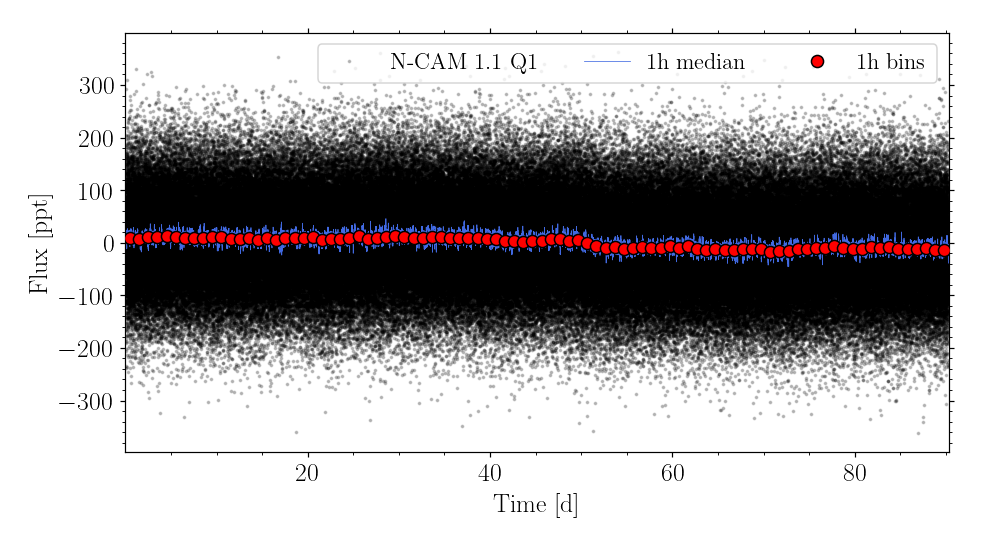

In [7]:
# Show a single light curve
lc = LightCurve(files[0], mode="single")
lc.plot(flux_unit='ppt', binsize=1, median_filter=1);

<IPython.core.display.Javascript object>


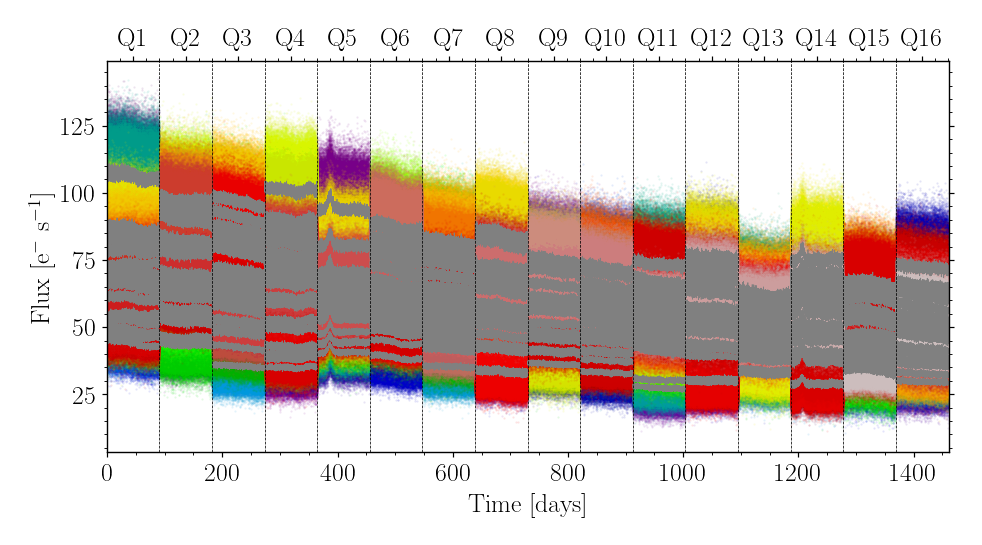

In [8]:
# Show all light curves from one group
fig, ax = lcs.plot_multi(suffix='hdf5', group=False, camera=False, quarter=False, 
                         flux_median=144, alpha=0.1, figsize=(9,5))

### Post-process a single camera light curve

In [9]:
# Load light curves of a single camera
lcs = LightCurve(odir, mode="multi")
files = lcs.files('hdf5', group=3, camera=1)
cadence = 25
binsize = 600
quarter = 16
nexp_per_quarter = 312113
nexp_per_bin = int(np.ceil(nexp_per_quarter * cadence / binsize))
mask_updates = np.arange(0, (quarter+1)*nexp_per_bin, nexp_per_bin).tolist()

In [10]:
# Merge all quarters
df0 = pd.DataFrame()
df1 = pd.DataFrame()
for f in files:
    lc = LightCurve(f)
    df1 = lc.bin(binsize=binsize/3600, time_unit='h')
    # Only allow flux measurements above threshold
    if df1.flux.median() < 5:
        df1.flux = np.ones_like(df1.flux.to_numpy) * np.nan
    else:
        df1.flux /= df1.flux.median() 
    # Store data frames
    df1.time *= 3600
    df0 = pd.concat([df0, df1])    
# Deep copy of base flux
df0['flux_base'] = df0.flux

<IPython.core.display.Javascript object>


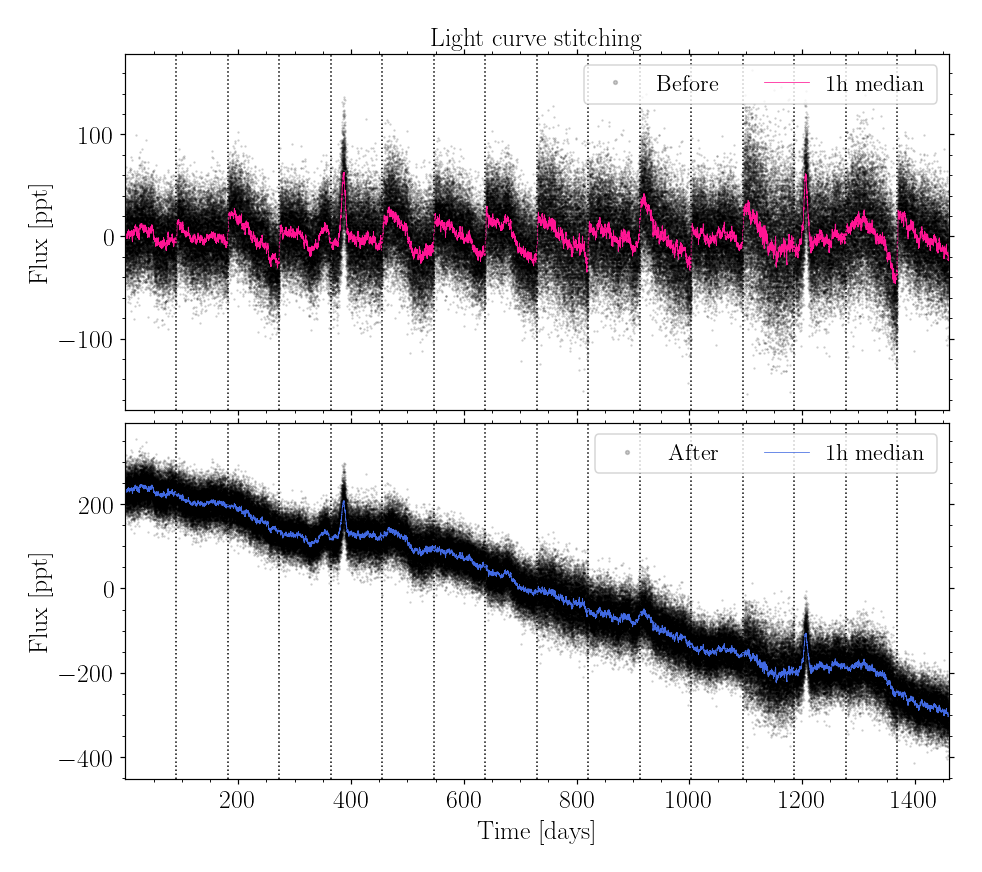

,time,flux,flux_base,flux_stitch,flux0
0,306.242311,1.038140,1.038140,1.038140,1.038140
1,906.226932,0.976102,0.976102,0.976102,0.976102
2,1506.211553,0.972240,0.972240,0.972240,0.972240
3,2106.196175,1.008207,1.008207,1.008207,1.008207
4,2706.180796,1.013759,1.013759,1.013759,1.013759


In [11]:
# Stitch the light curve
lc = LightCurve(df0, mode="multi")
df = lc.stitch(method='lowess', segment=5, mask_updates=mask_updates, plot=True)
df.head()

<IPython.core.display.Javascript object>


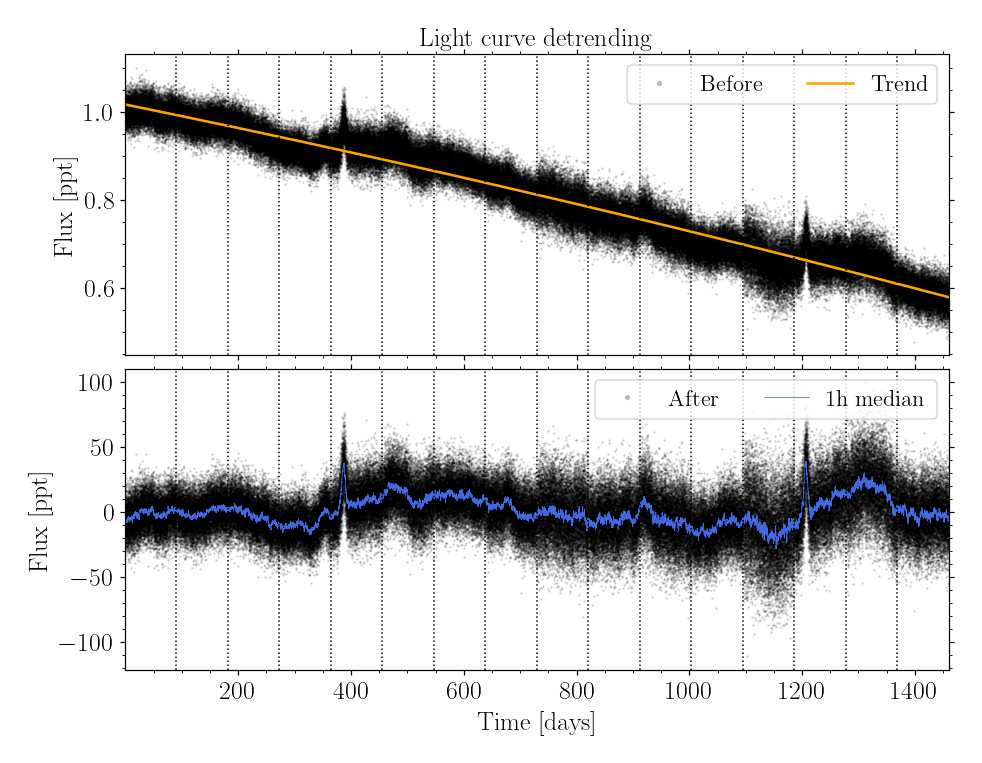

,time,flux,flux_base,flux_stitch,flux0,flux_trend,flux_detrend
0,306.242311,1.038140,1.038140,1.038140,1.038140,1.015997,1.010984
1,906.226932,0.976102,0.976102,0.976102,0.976102,1.015995,0.980212
2,1506.211553,0.972240,0.972240,0.972240,0.972240,1.015993,0.978297
3,2106.196175,1.008207,1.008207,1.008207,1.008207,1.015991,0.996139
4,2706.180796,1.013759,1.013759,1.013759,1.013759,1.015989,0.998894


In [12]:
# Linear detrend
df = lc.detrend(column='flux_stitch', model='poly', poly_degree=2, segments=False, plot=True)
df.head()

<IPython.core.display.Javascript object>


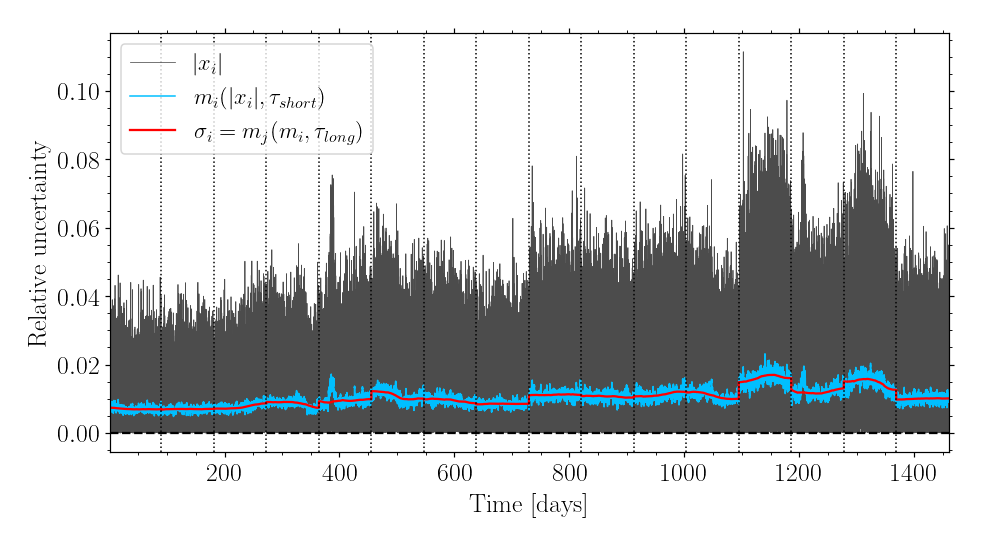

In [14]:
# Compute flux errors
df = lc.flux_error(column='flux_detrend', plot=True, short_filter=0.5, long_filter=50, type_filter=np.std)

<IPython.core.display.Javascript object>


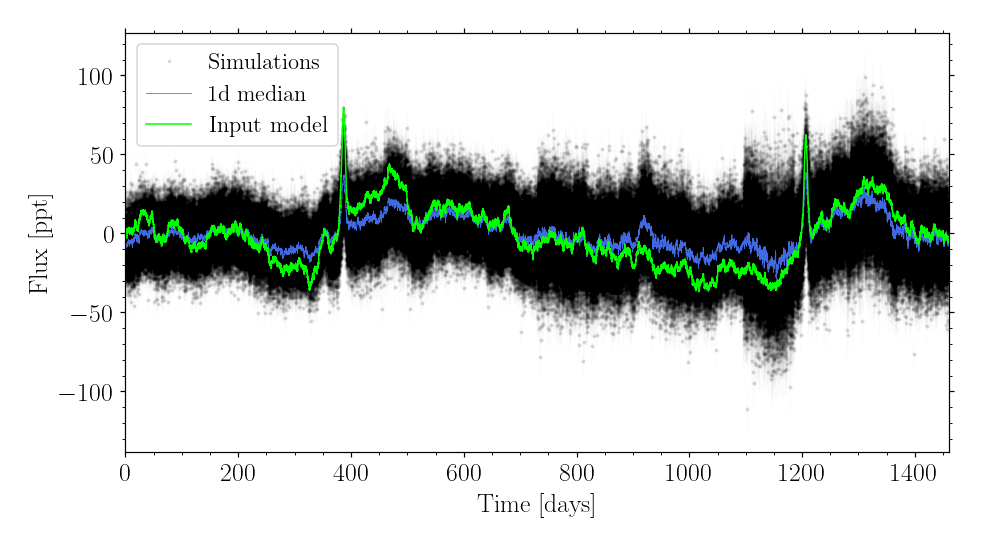

In [15]:
# Plot camera light curve with errors
time = df.time / 86400
flux = (df.flux_detrend - 1) * 1e3
ferr = df.flux_err * 1e3
fmed = median_filter(flux, 144)
fig = plt.figure(figsize=(9,5))
plt.errorbar(time, flux, yerr=ferr, fmt='.k', alpha=0.01, zorder=1)
plt.plot(time, flux, 'k.', ms=3, alpha=0.1, zorder=1, label='Simulations')
plt.plot(time, fmed, '-', c='royalblue', lw=0.5, label='1d median')
plt.plot(dv.time, dv.flux, '-', c='lime', lw=1.0, label='Input model')
plt.xlabel('Time [days]')
plt.ylabel('Flux [ppt]')
plt.xlim(0, time.max())
plt.legend(loc='best')
plt.tight_layout();

### Post-process to final light curves

In [16]:
def merge(lcs, cadence=25, binsize=600, quarters=16, segment=5, poly_degree=2, flux_thres=5):
    # Combine the two datasets while reducing each
    hour = 3600
    nexp_per_quarter = 312113
    nexp_per_bin = int(np.ceil(nexp_per_quarter * cadence / binsize))
    mask_updates = np.arange(0, (quarters + 1)*nexp_per_bin, nexp_per_bin).tolist()
    # Loop over each camera in each group
    dx = pd.DataFrame()
    for g in range(1,5):
        for c in tqdm(range(1,7), bar_format=ut.tqdmBar(), desc=f'Group {g}'):  
            # Merge all quarters
            df0 = pd.DataFrame()
            df1 = pd.DataFrame()
            files = lcs.files('hdf5', group=g, camera=c)
            for f in files:
                lc = LightCurve(f)
                df1 = lc.bin(binsize=binsize/hour, time_unit='h')
                # Only allow flux measurements above threshold [e-/s]
                if df1.flux.median() < flux_thres:
                    df1.flux = np.ones_like(df1.flux.to_numpy) * np.nan
                else:
                    df1.flux /= df1.flux.median() 
                # Store data frames
                df1.time *= hour 
                df0 = pd.concat([df0, df1])
            # Post-process full camera light curve
            lc = LightCurve(df0, mode="multi")
            lc.stitch(method='lowess', segment=segment, mask_updates=mask_updates)
            df = lc.detrend(column='flux_stitch', model='poly', poly_degree=poly_degree, 
                            segments=False, replace=True)
            df = lc.flux_error(short_filter=0.5, long_filter=50)
            dx = pd.concat([dx, df])  
    # Weighted average across equal timings
    dx = dx.reset_index()
    dx = dx.sort_values(by=['time'])
    dx['weight'] = 1 / dx.flux_err**2
    w = lambda x: np.average(x, weights=dx.loc[x.index, "weight"])
    e = lambda x: np.sqrt(1 / np.sum(dx.loc[x.index, "weight"])) 
    dx = dx.groupby(['time']).agg(flux=('flux', w), flux_err=('flux_err', e))
    dx = dx.reset_index()
    # Bin date to final light curve
    tbin = 3600
    tdur = dx.time.iloc[-1] - dx.time.iloc[0]
    bins = int(tdur/tbin)
    flux_bin, time_bin, _= binned_statistic(dx.time, dx.flux,     'median', bins)
    flux_err, time_bin, _= binned_statistic(dx.time, dx.flux_err, 'median', bins)
    flux_med = median_filter(flux_bin, 24)
    time_bin = time_bin[:-1] + np.diff(time_bin)[0]/2.
    dx = pd.DataFrame({'time':time_bin, 'flux':flux_bin, 'flux_med':flux_med, 'flux_err':flux_err})
    return dx

In [17]:
# Generate merged final light curve
lcs = LightCurve(odir, mode="multi")
df = merge(lcs, poly_degree=2, flux_thres=5)

Group 1: 100%|██████████████████████████████████████████████████| 6/6 [01:51<00:
Group 2: 100%|██████████████████████████████████████████████████| 6/6 [01:56<00:
Group 3: 100%|██████████████████████████████████████████████████| 6/6 [01:56<00:
Group 4: 100%|██████████████████████████████████████████████████| 6/6 [01:53<00:


<IPython.core.display.Javascript object>


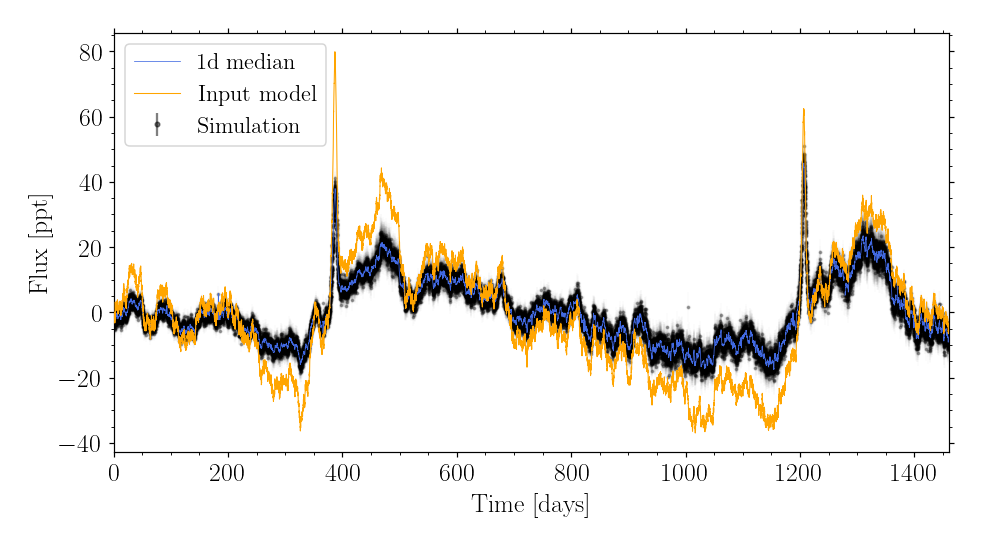

In [20]:
# Plot reduced light curve
fig = plt.figure(figsize=(9,5))
time = df.time / 86400
flux = (df.flux - 1) * 1e3
ferr = df.flux_err * 1e3
fmed = (df.flux_med - 1) * 1e3
plt.errorbar(time.iloc[0], flux.iloc[0], yerr=ferr.iloc[0], fmt='.k', alpha=0.5, label=r'Simulation', zorder=1)
plt.errorbar(time, flux, yerr=ferr, fmt='.k', alpha=0.01, zorder=1)
plt.plot(time,    flux,    '.', c='k', ms=3, alpha=0.3)
plt.plot(time,    fmed,    '-', c='royalblue', lw=0.5, label='1d median', zorder=2)
plt.plot(dv.time, dv.flux, '-', c='orange', lw=0.7, label='Input model', zorder=3)
plt.xlabel('Time [days]')
plt.ylabel('Flux [ppt]')
plt.xlim(0, time.max())
plt.legend(loc='best')
plt.tight_layout()

In [1]:
# # Stitch the light curve
# lc = LightCurve(df, mode="multi")
# df = lc.stitch(method='lowess', segment=5, mask_updates=mask_updates, plot=True)
# df.head()

In [29]:
# Save light curve
dx = pd.DataFrame()
dx['time'] = df.time / 86400    # [day]
dx['flux'] = df.flux / 1e3 + 1  # [pp1]
dx.to_feather(sdir / f'finals/lc_{filename}.ftr')
# Save figure
fig.savefig(fdir / f'lc_{filename}.png', bbox_inches='tight', dpi=300)
# Save simulation table
filename_tab = sdir / f'finals/table_{filename}.ftr'
dt = lcs.stat_sim_table(ofile=filename_tab, clean=True, verbose=True)

100%|██████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.53


In [33]:
dt.SPR.mean() * 100

2.4098087674457243